# 解答例（教員用）　第16回
***
> このノートブックは **模範解答の一例**です．コードの空欄（`TODO()`）を埋め，探索は複数ラウンドに分けて実行し，解答欄には実際に得られた出力の数値を根拠に書いています．
> 乱数を使う箇所は固定していますが，ライブラリのバージョンや実行環境によって数値が **小数第2〜3位ほどずれる**ことがあります．探索型の問題なので，**別の探索経路・別の最良設定でも，根拠が筋の通っていれば正解**です．

# 第16回　ANN と CNN・モデル比較
***
> **前提**: 第15回 SimpleMLP の続きです。第7回の線形回帰に相当する **LinearNet**（隠れ層なし），多層 **DeepMLP**，**SimpleCNN** の3モデルを同条件で学習し精度を比較します。第12回で学んだ混同行列も使います。

> ⚠️ **この課題で身につけること：ネットワークを一から書く力ではなく「AI（ニューラルネット）の中身の理解」です。**
>
> モデルのコードは**完成形で用意**しています。あなたの仕事は、(1) その構造を読み解いて説明すること、(2) ハイパーパラメータを変えて精度がどう動くかを実験すること、(3) 精度が伸びないときの対処を選ぶこと、です。各問のタグ：
>
> | タグ | 意味 | あなたがすること |
> |---|---|---|
> | **【骨格】** | 動くコードは与えられている | 設計上の決定点（層の幅・epoch・lr など）だけを変更する |
> | **【選択】** | 適切な手法を選ぶ問題 | 複数候補から選び、**理由**を解答用コードセルに書く |
> | **【実験】** | 試行錯誤の記録 | パラメータを変えて精度を表に記録し、**考察**する |
> | **【説明】** | 理解の証跡 | 与えられたコードの各行に `# 説明:` で意味を書く |
> | **【探索】** | 最適設定を自分で探す | **仮説 → 試行 → 記録 → 次の仮説** を何度も繰り返す。全試行が自動で履歴に残る |
>
> コードは原則として完成形ですが、**各問の「核心となる最低限の数行」は `# ★あなたが書く★` として空欄**にしてあります（学習ループの肝など）（空欄は `TODO()` と書いてあり、そのまま実行すると「空欄が残っています」というエラーで止まります。`TODO()` を自分のコードに書き換えてください）。AI に頼り切らず、要となる処理は自分で書けることも確認します。
>
> 各問の **✍️ 解答用コードセル**（`# (1-a)` 形式の変数・文字列）に、設計判断・理由・実験結果・考察を**項目ごとに**記入してください。これが採点対象です。

---

## 🧪 この回の進め方：最適な設定は「自分で」探す

この回では **「正解のパラメータ」は教えません**。答えは、あなたが何度も試して見つけます。

```
  ①仮説を立てる → ②試す（1回1行の記録が自動で残る） → ③結果を見て仮説を直す → ①へ戻る
```

### 試行錯誤の記録帳 `Lab`（最初のコードセルで用意済み。中身を読んで使い方を理解すること）

| 使い方 | 何をするか |
|---|---|
| `lab.df()` | これまでの全試行を表で見る（試行番号・設定・スコア・仮説） |
| `lab.plot(x="lr", group=...)` | 設定とスコアの関係、ベスト更新の推移をグラフにする |
| `lab.report()` | 探索の自己診断（回数・範囲・端に張り付いていないか・仮説を書いたか） |
| `lab.final_test(...)` | **テストデータでの最終評価。1回しか実行できない** |
| `lab.save()` | 全履歴を CSV に保存する |

### ルール（ここが「AIの理解」の中心）

1. **探索に使ってよいのは検証スコア（訓練データの一部を取り分けた検証用データでの正解率）だけ**。テストデータは最後に **1回だけ**（見てから設定を変えたらデータリーク）。
2. **試行のたびに「仮説」を書く**（何を確かめたい試行か）。やみくもな総当たりは評価されません。
3. **粗く → 細かく**：まず桁・範囲を広く振って良さそうな所を掴み、次にその周辺を細かく調べる。
4. **ベストが探索範囲の端に来たら、範囲を広げて確かめる**。
5. 上位の設定同士の差が、ばらつきより小さいなら「差がある」とは言えない。
6. **実験の前に予測を書く**。予測と結果のズレが、あなたが得た「知識」の証拠になる。
7. 最後に、得た知識を **LLM への指示書**にまとめる（最終問題）。

### 評価の観点

| 観点 | 見られること |
|---|---|
| 試行の量と質 | 目安回数以上・仮説が毎回ある・粗→細の流れがある |
| 結果の読み取り | 外れた仮説から何を学んだか（試行番号 `#n` を引用して書く） |
| 検証の作法 | テストは1回だけ／検証スコアとテストの差を正しく解釈している |
| 知識の言語化 | 自分の実験結果を、LLM が実行できる指示書に落とせている |

## 目次
1. 3モデルの実装
2. 学習と比較
3. 精度の棒グラフ
4. 混同行列とモデル保存

---

## この回で学ぶこと

### なぜ CNN が画像に強いのか

全結合層（MLP）の問題点：
- 28×28 = 784 ピクセルをすべてバラバラに扱う
- 「隣接するピクセルが関連している」という画像の構造的な情報を捨てる
- 画像が少し移動・回転するだけで全く異なる入力になる

CNN（Convolutional Neural Network）はこれを解決する：

```
【畳み込みの直感】
3×3 のフィルター（カーネル）が画像上をスライドしながら
局所的な特徴（エッジ，テクスチャ，形状）を検出する

第1層: エッジ検出（縦線，横線，斜め線）
第2層: テクスチャ（格子，波，点）
第3層: 形状（目，耳，数字の丸みなど）
```

### 畳み込み後の特徴マップサイズの計算

```
出力サイズ = (入力サイズ - カーネルサイズ + 2 × パディング) / ストライド + 1
```

今回の SimpleCNN：
```
入力: (28, 28)
Conv2d(1→16, kernel=3, padding=1): (28+2×1-3)/1+1 = 28 → (28, 28)
MaxPool2d(2): 28 / 2 = 14 → (14, 14)
Conv2d(16→32, kernel=3, padding=1): → (14, 14)
MaxPool2d(2): 14 / 2 = 7 → (7, 7)
→ 32チャネル × 7 × 7 = 1568次元 にFlatten
```

### MaxPooling の役割

- **ダウンサンプリング**：特徴マップを縮小して計算量を削減
- **位置不変性**：特徴が少し移動しても同じ出力（数字「3」が少し右に寄っていても認識できる）
- 各 2×2 領域の最大値を取るため，最も顕著な特徴を保持する

### モデルの保存と読み込み（state_dict）

学習済みモデルを保存する方法：
```python
torch.save(model.state_dict(), "model.pth")  # 重みパラメータのみ保存
```
モデル全体（構造 + 重み）を保存することも可能だが，`state_dict`（重みのみ）の保存が推奨される理由は：
- ファイルサイズが小さい
- Python バージョン間の互換性が高い
- 別のモデルに重みを転用しやすい（転移学習）

---

## 📚 将来の自分のためのメモ — 大学研究での応用


### どんな研究で使われるか

| 分野 | 具体例 |
|---|---|
| 医学画像 | X線・CT の病変検出，皮膚がん分類 |
| リモートセンシング | 衛星画像の土地利用分類，災害被害マッピング |
| 生物学 | 顕微鏡画像の細胞分類，プランクトン自動識別 |
| ロボティクス | 物体認識，自律走行の視覚モジュール |
| 文化財・人文 | 古文書の文字認識，美術品のスタイル分類 |

### 応用できる場面

- **画像・動画**など，空間的な局所パターンが重要なデータ
- 「ピクセル間の位置関係」をモデルに活かしたい
- **アーキテクチャ比較**（線形 vs MLP vs CNN）で論文の Contribution を示したい
- 学習済みモデルを `state_dict` で保存し，**推論・デプロイ**に回す（第17回）

### 応用しにくい・向かない場面

- **純粋な表形式データ**— CNN の畳み込みは意味をなさない
- **テキスト**— 近年は Transformer が主流（CNN は補助的）
- **データが極端に少ない**（数十枚）— 転移学習やデータ拡張なしでは過学習
- 比較実験で**エポック数・学習率・前処理がバラバラ**— 「CNN が勝った」とは言えない
- 混同行列で誤分類を見ても，**なぜ間違えたか**は別途 Grad-CAM などの可視化が必要

### 研究で報告するときのポイント

1. 比較するモデル間で**学習条件を統一**（本回の実験設計の要点）
2. 精度に加え**混同行列**でどのクラスを混同するか分析
3. ネットワーク構造（層数，チャネル数，カーネルサイズ）を図または表で記述
4. `state_dict` の保存形式と読み込み手順を再現可能に書く

### 関連する発展トピック（調べてみると良い）

- ResNet，EfficientNet（より深い CNN）
- 転移学習（ImageNet 事前学習の fine-tuning）
- Grad-CAM（どこを見て判断したかの可視化）

In [ ]:
%pip install -q torch torchvision


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import pandas as pd
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

DATA_ROOT = "./data"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.ToTensor()
train_dataset = datasets.MNIST(root=DATA_ROOT, train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root=DATA_ROOT, train=False, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# 検証用データ：訓練データの 50000〜52000 番を取り分ける（学習に使わない）。test_loader は最終評価の1回だけに使う
val_loader = DataLoader(Subset(train_dataset, range(50000, 52000)), batch_size=500, shuffle=False)


# ==== 試行錯誤の記録帳（この回の全実験がここに溜まる。中身を読んで使い方を理解しておくこと）====
class Lab:
    """試行錯誤の記録帳。何回でも log() でき、表・グラフ・診断レポートにできる。
    ・スコア（score）は「検証用スコア（CV など）」だけを記録する。テストデータは final_test() で1回だけ。
    ・bounds = {パラメータ名: (下限, 上限)} … それ以上広げられない値（例：k の下限 2）。ベストがここにあっても「端」と警告しない。
    ・ignore = {パラメータ名: [値, ...]} … 範囲の計算から外す特別な値（例：正則化なしを表す alpha=0）。"""

    def __init__(self, name, score_name="cv_score", higher_is_better=True, bounds=None, ignore=None):
        self.name, self.score_name, self.hib = name, score_name, higher_is_better
        self.bounds, self.ignore = bounds or {}, ignore or {}
        self.rows, self.test_result = [], None

    def seen(self, params):
        return any(r["params"] == params for r in self.rows)

    def log(self, hypothesis, params, score, **extra):
        """1試行を記録する。同じ params を再度記録しようとすると無視する（重複の水増し防止）。"""
        if self.seen(params):
            print(f"  (skip) 既に試した設定です: {params}")
            return
        self.rows.append(dict(trial=len(self.rows) + 1, hypothesis=hypothesis.strip(),
                              params=dict(params), score=float(score), extra=extra))
        best = self.best()["trial"] == len(self.rows)
        print(f"  #{len(self.rows):02d} {params}  {self.score_name}={score:.4f}"
              + "".join(f"  {k}={v}" for k, v in extra.items()) + ("  ★ベスト更新" if best else ""))

    def df(self):
        import pandas as pd
        return pd.DataFrame([{"trial": r["trial"], **r["params"], self.score_name: round(r["score"], 4),
                              **r["extra"], "hypothesis": r["hypothesis"]} for r in self.rows])

    def best(self):
        return (max if self.hib else min)(self.rows, key=lambda r: r["score"])

    def plot(self, x, group=None, logx=True, query=None):
        """パラメータ x とスコアの関係（group ごとに線を分ける）と、試行回数ごとのベスト更新の推移。"""
        if not self.rows:
            print("まだ試行がありません（上の探索セルの TODO() を埋めて実行してください）"); return
        import matplotlib.pyplot as plt
        d = self.df()
        dd = d.query(query) if query else d
        fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
        for g, sub in (dd.groupby(group) if group else [("all", dd)]):
            sub = sub.sort_values(x)
            ax[0].plot(sub[x], sub[self.score_name], "o-", label=str(g))
        if logx and dd[x].dtype.kind in "if" and (dd[x] > 0).all(): ax[0].set_xscale("log")
        ax[0].set_xlabel(x); ax[0].set_ylabel(self.score_name); ax[0].legend(); ax[0].set_title("Parameter vs. validation score")
        cur = d[self.score_name].cummax() if self.hib else d[self.score_name].cummin()
        ax[1].step(d["trial"], cur, where="post"); ax[1].plot(d["trial"], d[self.score_name], "x", alpha=.5)
        ax[1].set_xlabel("Trial number"); ax[1].set_title("Best score so far (flat = plateau)")
        plt.tight_layout(); plt.show()

    def report(self, min_trials=15):
        """探索の質の自己診断：回数・カバー範囲・端に張り付いていないか・仮説を書いたか。"""
        if not self.rows:
            print("まだ試行がありません（上の探索セルの TODO() を埋めて実行してください）"); return
        d, n = self.df(), len(self.rows)
        print(f"■ 試行回数: {n}（目安 {min_trials} 回以上） → {'OK' if n >= min_trials else 'まだ足りない'}")
        keys = list(self.rows[0]["params"]) if n else []
        b = self.best()
        print(f"■ ベスト: trial#{b['trial']} {b['params']}  {self.score_name}={b['score']:.4f}")
        for k in keys:
            vals = [r["params"][k] for r in self.rows if r["params"][k] not in self.ignore.get(k, [])]
            uniq = sorted(set(map(str, vals)))
            line = f"■ {k}: {len(uniq)} 種類を試した"
            nums = [v for v in vals if isinstance(v, (int, float)) and not isinstance(v, bool)]
            if k != "seed" and vals and len(nums) == len(vals) and len(set(nums)) > 2:
                lo, hi = min(nums), max(nums)
                blo, bhi = self.bounds.get(k, (None, None))
                bv = b["params"][k]
                edge = (bv == lo and lo != blo) or (bv == hi and hi != bhi)
                line += f"（範囲 {lo:g}〜{hi:g}）" + (" ⚠ ベストが探索範囲の端 → 範囲を広げて確かめよう" if edge else "")
            print(line)
        w = sum(1 for r in self.rows if len(r["hypothesis"]) >= 8)
        print(f"■ 仮説を書いた試行: {w}/{n}" + ("" if w == n else " ⚠ 何を確かめる試行か毎回書こう"))
        if n >= 6:
            third = n // 3
            print(f"■ 前半の最高 {d[self.score_name][:third].max():.4f} → 後半の最高 {d[self.score_name][-third:].max():.4f}")

    def final_test(self, score_fn, name="最終テストスコア", compare=True):
        """テストデータでの最終評価。1回しか実行できない（2回目以降はエラー）。
        compare=False は、検証スコアと別の指標で評価するとき（並べて比べられないので表示しない）。"""
        if self.test_result is not None:
            raise RuntimeError(f"テストは既に使用済みです（結果 {self.test_result:.4f}）。テストを見て設定を変えるのはデータリークです。")
        self.test_result = float(score_fn())
        print(f"{name} = {self.test_result:.4f}"
              + (f"   （検証ベスト {self.score_name} = {self.best()['score']:.4f}）" if compare else ""))
        return self.test_result

    def save(self, path=None):
        path = path or f"{self.name}_log.csv"
        self.df().to_csv(path, index=False, encoding="utf-8-sig"); print("保存:", path)


def TODO():
    """「★あなたが書く★」の空欄。自分のコードに置き換えるまで、実行するとここで止まる。"""
    raise NotImplementedError("★あなたが書く★ の空欄（TODO()）がまだ残っています。自分のコードに書き換えてから再実行してください。")


## 問題1　3モデルの構造を読み解く　【説明】
***

### 3モデルの役割と比較の意義

今回実装する3モデルは，複雑さの段階的な比較になっている：

| モデル | 複雑さ | 特徴 |
|---|---|---|
| `LinearNet` | 最も単純（線形） | 隠れ層なし。784→10 の直接マッピング。ベースライン |
| `DeepMLP` | 中程度（非線形，多層） | 隠れ層2つ。非線形パターンを学習できる |
| `SimpleCNN` | 最も複雑（空間構造を活用） | 畳み込みで画像の局所特徴を抽出 |

同じデータ・同じ条件で比較することで，「モデルの複雑さ」の効果を純粋に検証できる。

### `DeepMLP` の実装について

`SimpleMLP`（問題15）との違いは隠れ層が2つになること：
```
784 → [Linear(784,256)] → [ReLU] → [Linear(256,128)] → [ReLU] → [Linear(128,10)]
```

層を増やすと：
- より複雑なパターンを学習できる
- 計算量が増える
- 過学習しやすくなる（Dropoutなどの正則化が必要になることも）

### `SimpleCNN` の実装について

CNN では `nn.Sequential` を使うと層をまとめて書ける：
```python
self.conv_block = nn.Sequential(
    nn.Conv2d(1, 16, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Conv2d(16, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),
)
```

### 課題

下のコードセルには、3つのモデル（`LinearNet` / `DeepMLP` / `SimpleCNN`）が **完成形で実装**されています。今回はネットワークを一から書くのではなく、**「なぜこの構造でうまくいくのか」を読み解く**のが目的です。

**各行の `# 説明:` の右に、その行が何をしているかを自分の言葉で書いて**ください（コードは変更しない）。書き終えたら実行し、各モデルのパラメータ数を確認してください。

説明を書くときは、次の問いを意識してください：

- `LinearNet` と `DeepMLP` の違いは何か？ なぜ MLP の方が複雑なパターンを学習できるのか？
- CNN の特徴マップのサイズはなぜ `28 → 14 → 7` と変わるのか？（`MaxPool2d(2)` の役割）
- 最後の全結合層の入力がなぜ `32 × 7 × 7` なのか？
- `kernel_size=3, padding=1` にすると畳み込み後もサイズが 28 のまま保たれるのはなぜか？

> **考察（パラメータ数）**: 出力されるパラメータ数を見て、`SimpleCNN` は `DeepMLP` より層が深いのに**パラメータ数はむしろ少ない**かもしれません。なぜだと思いますか？（ヒント：畳み込みは「同じフィルターを画像全体で使い回す」）

In [2]:
# 完成形のモデル定義です。各行の「# 説明:」に自分の言葉で意味を書いてください。
# （コードは変更しない。説明は AI に書かせず自分で書くこと）

class LinearNet(nn.Module):
    """隠れ層なし（線形）。第7回の線形モデルに相当するベースライン。"""
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(28 * 28, 10)             # 説明: 隠れ層なしの全結合層 1 つ（784 入力 → 10 出力）．画素の重み付き和だけで 10 クラスのスコアを出す線形モデル．

    def forward(self, x):
        x = x.view(x.size(0), -1)                    # 説明: (バッチ, 1, 28, 28) の画像を (バッチ, 784) に平坦化する．
        return self.fc(x)


class DeepMLP(nn.Module):
    """多層全結合 ANN。hidden1/hidden2 は実験で変えられるよう引数化。"""
    def __init__(self, hidden1=256, hidden2=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(28 * 28, hidden1),             # 説明: 784 個の入力から第 1 隠れ層の hidden1 個（既定 256）のユニットへ線形変換する層．
            nn.ReLU(),                               # 説明: 負の値を 0 にする非線形の活性化関数．線形層を重ねても 1 つの線形変換にしかならないので，間に非線形を入れて複雑なパターンを学習できるようにする．
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, 10),                  # 説明: 出力層．10 は 0〜9 の 10 クラスに対応するスコア（logits）の数．
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.net(x)


class SimpleCNN(nn.Module):
    """畳み込みで画像の局所特徴を抽出する。"""
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),   # 説明: 3×3 のフィルター 16 枚で畳み込む（入力 1 チャンネル → 出力 16 チャンネル）．padding=1 なので縦横 28×28 のまま保たれ，形は (16, 28, 28)．
            nn.ReLU(),
            nn.MaxPool2d(2),                              # 説明: 2×2 の窓ごとに最大値だけを残して縦横を半分にする（28 → 14）．位置のずれに強くなり，計算量も減る．
            nn.Conv2d(16, 32, kernel_size=3, padding=1),  # 説明: 3×3 のフィルター 32 枚で畳み込む（16 → 32 チャンネル）．padding=1 でサイズは 14×14 のまま，形は (32, 14, 14)．
            nn.ReLU(),
            nn.MaxPool2d(2),                              # 説明: 2 回目の MaxPool2d(2) で縦横がさらに半分（14 → 7）になる．畳み込み（padding=1）はサイズを変えず，プーリングだけが 1/2 にするので 28 → 14 → 7．
        )
        self.fc = nn.Sequential(
            nn.Linear(32 * 7 * 7, 128),                   # 説明: 畳み込み・プーリング後の特徴マップは 32 チャンネル × 7 × 7 で，これを平坦化すると 32×7×7 = 1568 個になる．それが全結合層（1568 → 128）の入力次元．
            nn.ReLU(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)                         # 説明: (バッチ, 32, 7, 7) の特徴マップを (バッチ, 1568) に平坦化して，全結合層に渡せる形にする．
        return self.fc(x)


# パラメータ数の確認（実行するだけ）
for name, model in [("LinearNet", LinearNet()), ("DeepMLP", DeepMLP()), ("SimpleCNN", SimpleCNN())]:
    n_params = sum(p.numel() for p in model.parameters())
    print(f"{name:10s}: パラメータ数 = {n_params:,}")


LinearNet : パラメータ数 = 7,850
DeepMLP   : パラメータ数 = 235,146
SimpleCNN : パラメータ数 = 206,922


### 各層を通ったあとの形を見てみよう（実行するだけ）

`SimpleCNN` に 1 枚の画像を通し，**層ごとにデータの形がどう変わるか**を表示します．説明を書くときの手がかりにしてください．

In [3]:
# === 形の変化を確認する（実行するだけ。コードは変更しない）===
_x = next(iter(train_loader))[0][:1]            # 1 枚の画像 (1, 1, 28, 28)
print("入力:", tuple(_x.shape))
_cnn = SimpleCNN()
for _layer in _cnn.conv:
    _x = _layer(_x)
    print(f"{_layer.__class__.__name__:10s} -> {tuple(_x.shape)}")
_x = _x.view(_x.size(0), -1)
print(f"{'flatten':10s} -> {tuple(_x.shape)}")
for _layer in _cnn.fc:
    _x = _layer(_x)
    print(f"{_layer.__class__.__name__:10s} -> {tuple(_x.shape)}")

入力: (1, 1, 28, 28)
Conv2d     -> (1, 16, 28, 28)
ReLU       -> (1, 16, 28, 28)
MaxPool2d  -> (1, 16, 14, 14)
Conv2d     -> (1, 32, 14, 14)
ReLU       -> (1, 32, 14, 14)
MaxPool2d  -> (1, 32, 7, 7)
flatten    -> (1, 1568)
Linear     -> (1, 128)
ReLU       -> (1, 128)
Linear     -> (1, 10)


[W NNPACK.cpp:64] Could not initialize NNPACK! Reason: Unsupported hardware.


In [4]:
# === ✍️ 問題1 解答（採点対象）===
# 主な提出物は上のコードセルへの # 説明: 記入。以下も記入すること。

# (1-a) `LinearNet` と `DeepMLP` の違い／なぜ MLP は複雑なパターンを学習できるのか
answer_1_a = """
LinearNet は隠れ層が無く、784 画素の重み付き和だけで 10 クラスのスコアを出す線形モデル（直線的な境界しか作れない）。DeepMLP は隠れ層を 2 層持ち、間に ReLU（非線形）を挟むので、線形では表せない曲がった境界や、画素の組合せによる特徴（パターン）を学習できる。
"""

# (1-b) CNN の特徴マップが `28 → 14 → 7` と変わる理由（`MaxPool2d(2)` の役割）
answer_1_b = """
Conv2d(kernel=3, padding=1) は縦横のサイズを保つ（28→28）。サイズを変えるのは MaxPool2d(2) で、2×2 の窓の最大値だけを残して縦横を半分にする。1 回目で 28 → 14、2 回目で 14 → 7。位置のずれに強くなり、パラメータ・計算量も減る。
"""

# (1-c) 最後の全結合層の入力がなぜ `32 × 7 × 7` なのか
answer_1_c = """
畳み込み・プーリングを経た特徴マップは、チャンネル数が 32、縦横が 7×7。全結合層に入れるために平坦化すると 32 × 7 × 7 = 1568 個の値になるので、それが全結合層（1568 → 128）の入力次元になる。（実行出力の「flatten -> (1, 1568)」と一致）
"""

# (1-d) 各モデルのパラメータ数（実行結果）：LinearNet=　/ DeepMLP=　/ SimpleCNN=
answer_1_d = """
LinearNet = 7,850 / DeepMLP = 235,146 / SimpleCNN = 206,922
"""

# (1-e) 考察：SimpleCNN は層が深いのにパラメータ数が少ない（ことがある）理由
answer_1_e = """
畳み込み層は「小さなフィルター（3×3）を画像全体で使い回す」（重み共有）ので、パラメータ数がフィルターの大きさ×枚数（Conv2d(1,16,3) は 16×(1×3×3)+16 = 160 個）しか要らず、画像の大きさに依存しない。一方、全結合層（DeepMLP の 784 → 256 は 784×256 = 200,704 個）は入力の画素ごとに独立な重みを持つのでパラメータが多い。SimpleCNN は全結合層（1568 → 128 = 200,832 個）が大半を占めている。
"""



## 問題2　3モデルの最適な学習設定を自分で探す　【骨格+探索】
***

### 課題

`train_one_model` 関数の **学習の核心（順伝播→損失→逆伝播→更新の4ステップ）はあなたが書きます**（`# ★あなたが書く★`）。ここはニューラルネット学習の心臓部なので、必ず自分で書いてください。

書けたら、**検証精度が最も高い「モデル × 設定」を自分で探し当てて**ください。探す軸：

| 軸 | 選択肢 | 注意点 |
|---|---|---|
| `model` | `"LinearNet"` / `"DeepMLP"` / `"SimpleCNN"` | 複雑なほど良いとは限らない？ |
| `lr` | 学習率（Adam）。0.00003〜0.03 など桁で振る | 大きすぎ・小さすぎの両方に罠がある |
| `epochs` | 1〜8 | 増やすと過学習・時間増 |
| `hidden1` | DeepMLP の第1隠れ層 32〜512（他モデルでは無視される。`None`） | |
| `batch_size` | 16〜256 | 小さいほど更新回数が増える |

学習は訓練データの **先頭 `N_TRAIN` 枚（既定 12000）**、検証は訓練データ内の別の 2000 枚（`val_loader`）です。**テストデータは問題4の最終評価の 1回だけ**。各試行では `train_acc`・`val_acc`・`gap`（過学習の度合い）・`n_params`（パラメータ数）・`sec`（所要時間）も記録します。

> **注意**: 1回の学習結果は乱数でわずかに変わります。**0.003 程度の差は「差がある」と言い切れません。**

1. **【実験前に先に書く】** 予測セルに、3モデルの精度の順位と最良設定の予測と理由を書く。
2. 探索セルの `hypothesis` と `settings` を書き換えて何度も実行（**15回以上**、3モデルすべてと `lr` を含む3軸以上を動かす）。
3. 経過確認セルで確認して次の一手を決める。
4. 解答セルに書く。**最終評価（テスト 1回）は問題4**で行います。

> **考察1**: `LinearNet < DeepMLP < SimpleCNN` の順に精度が上がりましたか？ 予想と違ったら何が原因だと思いますか？
>
> **考察2**: `lr` を大きくしすぎたとき精度が不安定になるのはなぜですか？（試行番号を引用）
>
> **考察3（コストと精度）**: `n_params`・`sec` と `val_acc` の関係を見て、「精度を 0.5 ポイント上げるのに何倍のコストがかかったか」を1例挙げてください。

In [5]:
# === ✍️ 問題2-0 実験前の予測（実験を始める前に書く。実験後に書き直さない）===

# 検証精度が高いと思う順にモデル名を並べる（例："SimpleCNN > DeepMLP > LinearNet"）と、最良だと思う lr
prediction_2_ranking = "SimpleCNN > DeepMLP > LinearNet"
prediction_2_lr = 0.001
# そう予測した理由（知識・直感・LLMの回答など。LLMに聞いた場合は回答を貼り、自分との違いも書く）
prediction_2_reason = """
画像の局所的な特徴（線・角）を捉えられる CNN が最も良く、次に非線形を持つ MLP、最後に線形のモデルだと予想した。Adam の学習率は標準の 0.001 が最良に近いと考えた（LLM に聞いても同様の回答）。
"""

In [6]:
# === 完成済みコード（★の箇所だけ自分で書く）：試す → lab に記録、を繰り返せる形になっている ===
import time
lab = Lab("q16_models", score_name="val_acc")
N_TRAIN = 12000                                   # 探索時の学習枚数（少ないほど速い）
train_subset = Subset(train_dataset, range(N_TRAIN))
train_eval_loader = DataLoader(Subset(train_dataset, range(2000)), batch_size=500)   # 訓練精度の測定用（学習に使った 2000 枚）

def train_one_model(model, train_loader, eval_loader, epochs=3, lr=0.001):
    """model を train_loader で学習し、eval_loader での正解率を返す（q15 の学習ループと同じ）"""
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            # ★あなたが書く★：学習の4ステップ（勾配初期化→順伝播で損失→逆伝播→パラメータ更新）
            #   ヒント: optimizer.zero_grad() / loss = criterion(model(images), labels)
            #           / loss.backward() / optimizer.step() の4行
            optimizer.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()
    return accuracy_of(model, eval_loader)


def accuracy_of(model, loader):
    """loader 全体での正解率"""
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            correct += (model(images).argmax(dim=1) == labels).sum().item()
            total += labels.size(0)
    return correct / total


def build_model(name, hidden1=None):
    if name == "DeepMLP":
        return DeepMLP(hidden1=hidden1 or 256)
    return {"LinearNet": LinearNet, "SimpleCNN": SimpleCNN}[name]()


def run_trial(hypothesis, name, lr, epochs, hidden1, batch_size):
    """1つの設定を試して lab に記録する（同じ設定は2回記録されない）"""
    params = {"model": name, "lr": lr, "epochs": epochs,
              "hidden1": hidden1 if name == "DeepMLP" else None, "batch_size": batch_size}
    if lab.seen(params):
        print(f"  (skip) 既に試した設定です: {params}"); return
    torch.manual_seed(0)
    t0 = time.time()
    model = build_model(name, hidden1)
    loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
    val_acc = train_one_model(model, loader, val_loader, epochs=epochs, lr=lr)
    train_acc = accuracy_of(model, train_eval_loader)
    lab.log(hypothesis, params, val_acc,
            train_acc=round(train_acc, 4), gap=round(train_acc - val_acc, 4),
            n_params=sum(p.numel() for p in model.parameters()), sec=round(time.time() - t0, 1))

# === ★ここを変えて実験する★：仮説を書き、settings を書き換えて何度でも実行 ===
# 【変更のしかた】
#  ① hypothesis … 今回の試行で「何を確かめたいか」を1文で書き換える（例：「alpha を10倍にすると CV は上がるはず」）。空・短すぎると report で警告される
#  ② settings   … 試したい設定を「1行に1つのタプル」で並べる。タプルの並び順は (model, lr, epochs, hidden1, batch_size)
#       model … "LinearNet" / "DeepMLP" / "SimpleCNN"
#       lr … Adam の学習率（0.00003〜0.03 を桁で）
#       epochs … 学習回数（1〜8）
#       hidden1 … DeepMLP の第1隠れ層の幅（32〜512）。他のモデルでは None と書く
#       batch_size … ミニバッチの大きさ（16〜256）
#     行を足す／消す／数値を書き換えてよい。例：settings = [("LinearNet", 0.001, 2, None, 64), ("DeepMLP", 0.001, 2, 256, 64), ("SimpleCNN", 0.001, 2, None, 64)]
#  ③ 実行すると、この settings の各行が1試行として lab に記録される（前に試した試行は消えず、同じ設定は重複記録されない）
#  ④ 下の「経過の確認」セルで結果を見て、①②を書き換えて再実行する（これを何回も繰り返す）
#  ※ 15 回以上。3 モデルすべてと lr を含む 3 軸以上を動かすこと。
# 進め方の例： ①3モデルを同条件で比べる → ②lr を桁で振る → ③良さそうなモデルで epochs・hidden1・batch_size を動かす
hypothesis = "まず lr=0.001, epochs=2 に固定して3モデルを同条件で比べる"
settings = [                       # (model, lr, epochs, hidden1, batch_size)
    ("LinearNet", 0.001, 2, None, 64),
    ("DeepMLP",   0.001, 2, 256,  64),
    ("SimpleCNN", 0.001, 2, None, 64),
]
for name, lr, epochs, h1, bs in settings:
    run_trial(hypothesis, name, lr, epochs, h1, bs)

  #01 {'model': 'LinearNet', 'lr': 0.001, 'epochs': 2, 'hidden1': None, 'batch_size': 64}  val_acc=0.8900  train_acc=0.886  gap=-0.004  n_params=7850  sec=2.8  ★ベスト更新


  #02 {'model': 'DeepMLP', 'lr': 0.001, 'epochs': 2, 'hidden1': 256, 'batch_size': 64}  val_acc=0.9105  train_acc=0.924  gap=0.0135  n_params=235146  sec=4.0  ★ベスト更新


  #03 {'model': 'SimpleCNN', 'lr': 0.001, 'epochs': 2, 'hidden1': None, 'batch_size': 64}  val_acc=0.9555  train_acc=0.9605  gap=0.005  n_params=206922  sec=9.6  ★ベスト更新


In [7]:
hypothesis = "lr を 10 倍・1/10 に変えて、モデルごとの最適な lr の方向を見る"
settings = [("LinearNet", 0.01, 2, None, 64), ("DeepMLP", 0.01, 2, 256, 64), ("SimpleCNN", 0.01, 2, None, 64), ("DeepMLP", 0.0001, 2, 256, 64), ("SimpleCNN", 0.0001, 2, None, 64)]
for name, lr, epochs, h1, bs in settings:
    run_trial(hypothesis, name, lr, epochs, h1, bs)

  #04 {'model': 'LinearNet', 'lr': 0.01, 'epochs': 2, 'hidden1': None, 'batch_size': 64}  val_acc=0.9065  train_acc=0.928  gap=0.0215  n_params=7850  sec=2.9


  #05 {'model': 'DeepMLP', 'lr': 0.01, 'epochs': 2, 'hidden1': 256, 'batch_size': 64}  val_acc=0.9165  train_acc=0.946  gap=0.0295  n_params=235146  sec=4.0


  #06 {'model': 'SimpleCNN', 'lr': 0.01, 'epochs': 2, 'hidden1': None, 'batch_size': 64}  val_acc=0.9630  train_acc=0.976  gap=0.013  n_params=206922  sec=9.0  ★ベスト更新


  #07 {'model': 'DeepMLP', 'lr': 0.0001, 'epochs': 2, 'hidden1': 256, 'batch_size': 64}  val_acc=0.8615  train_acc=0.865  gap=0.0035  n_params=235146  sec=4.7


  #08 {'model': 'SimpleCNN', 'lr': 0.0001, 'epochs': 2, 'hidden1': None, 'batch_size': 64}  val_acc=0.8550  train_acc=0.859  gap=0.004  n_params=206922  sec=8.7


,trial,model,lr,epochs,hidden1,batch_size,val_acc,train_acc,gap,n_params,sec
5,6,SimpleCNN,0.0100,2,NaN,64,0.9630,0.9760,0.0130,206922,9.0
2,3,SimpleCNN,0.0010,2,NaN,64,0.9555,0.9605,0.0050,206922,9.6
4,5,DeepMLP,0.0100,2,256.0,64,0.9165,0.9460,0.0295,235146,4.0
1,2,DeepMLP,0.0010,2,256.0,64,0.9105,0.9240,0.0135,235146,4.0
3,4,LinearNet,0.0100,2,NaN,64,0.9065,0.9280,0.0215,7850,2.9
0,1,LinearNet,0.0010,2,NaN,64,0.8900,0.8860,-0.0040,7850,2.8
6,7,DeepMLP,0.0001,2,256.0,64,0.8615,0.8650,0.0035,235146,4.7
7,8,SimpleCNN,0.0001,2,NaN,64,0.8550,0.8590,0.0040,206922,8.7


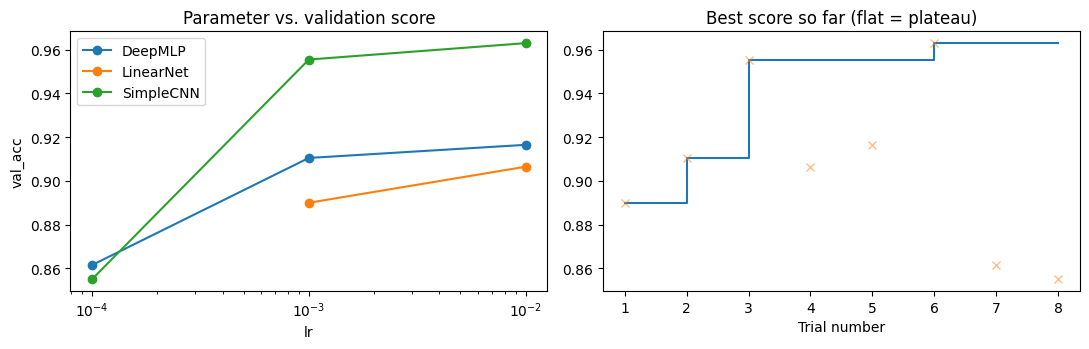

■ 試行回数: 8（目安 15 回以上） → まだ足りない
■ ベスト: trial#6 {'model': 'SimpleCNN', 'lr': 0.01, 'epochs': 2, 'hidden1': None, 'batch_size': 64}  val_acc=0.9630
■ model: 3 種類を試した
■ lr: 3 種類を試した（範囲 0.0001〜0.01） ⚠ ベストが探索範囲の端 → 範囲を広げて確かめよう
■ epochs: 1 種類を試した
■ hidden1: 2 種類を試した
■ batch_size: 1 種類を試した
■ 仮説を書いた試行: 8/8
■ 前半の最高 0.9105 → 後半の最高 0.8615
探索に使った時間の合計: 46 秒


In [8]:
# === 経過の確認（何度でも実行）：次の一手を決める材料 ===
display(lab.df().drop(columns="hypothesis").sort_values("val_acc", ascending=False).head(8))
lab.plot(x="lr", group="model")                # lr と検証精度、ベスト更新の推移
lab.report(min_trials=15)
print("探索に使った時間の合計: %.0f 秒" % sum(r["extra"]["sec"] for r in lab.rows))

In [9]:
hypothesis = "lr を桁の間（0.003）と上（0.03）で確認。山の位置を絞る"
settings = [("DeepMLP", 0.03, 2, 256, 64), ("SimpleCNN", 0.03, 2, None, 64), ("DeepMLP", 0.003, 2, 256, 64), ("SimpleCNN", 0.003, 2, None, 64)]
for name, lr, epochs, h1, bs in settings:
    run_trial(hypothesis, name, lr, epochs, h1, bs)

  #09 {'model': 'DeepMLP', 'lr': 0.03, 'epochs': 2, 'hidden1': 256, 'batch_size': 64}  val_acc=0.9125  train_acc=0.9415  gap=0.029  n_params=235146  sec=4.1


  #10 {'model': 'SimpleCNN', 'lr': 0.03, 'epochs': 2, 'hidden1': None, 'batch_size': 64}  val_acc=0.9245  train_acc=0.938  gap=0.0135  n_params=206922  sec=8.9


  #11 {'model': 'DeepMLP', 'lr': 0.003, 'epochs': 2, 'hidden1': 256, 'batch_size': 64}  val_acc=0.9320  train_acc=0.9485  gap=0.0165  n_params=235146  sec=5.7


  #12 {'model': 'SimpleCNN', 'lr': 0.003, 'epochs': 2, 'hidden1': None, 'batch_size': 64}  val_acc=0.9745  train_acc=0.977  gap=0.0025  n_params=206922  sec=9.4  ★ベスト更新


,trial,model,lr,epochs,hidden1,batch_size,val_acc,train_acc,gap,n_params,sec
11,12,SimpleCNN,0.003,2,NaN,64,0.9745,0.9770,0.0025,206922,9.4
5,6,SimpleCNN,0.010,2,NaN,64,0.9630,0.9760,0.0130,206922,9.0
2,3,SimpleCNN,0.001,2,NaN,64,0.9555,0.9605,0.0050,206922,9.6
10,11,DeepMLP,0.003,2,256.0,64,0.9320,0.9485,0.0165,235146,5.7
9,10,SimpleCNN,0.030,2,NaN,64,0.9245,0.9380,0.0135,206922,8.9
4,5,DeepMLP,0.010,2,256.0,64,0.9165,0.9460,0.0295,235146,4.0
8,9,DeepMLP,0.030,2,256.0,64,0.9125,0.9415,0.0290,235146,4.1
1,2,DeepMLP,0.001,2,256.0,64,0.9105,0.9240,0.0135,235146,4.0


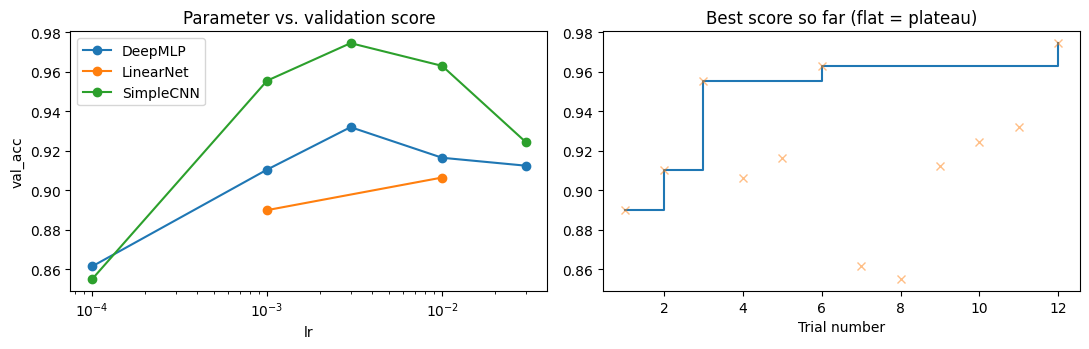

■ 試行回数: 12（目安 15 回以上） → まだ足りない
■ ベスト: trial#12 {'model': 'SimpleCNN', 'lr': 0.003, 'epochs': 2, 'hidden1': None, 'batch_size': 64}  val_acc=0.9745
■ model: 3 種類を試した
■ lr: 5 種類を試した（範囲 0.0001〜0.03）
■ epochs: 1 種類を試した
■ hidden1: 2 種類を試した
■ batch_size: 1 種類を試した
■ 仮説を書いた試行: 12/12
■ 前半の最高 0.9555 → 後半の最高 0.9745
探索に使った時間の合計: 74 秒


In [10]:
# === 経過の確認（何度でも実行）：次の一手を決める材料 ===
display(lab.df().drop(columns="hypothesis").sort_values("val_acc", ascending=False).head(8))
lab.plot(x="lr", group="model")                # lr と検証精度、ベスト更新の推移
lab.report(min_trials=15)
print("探索に使った時間の合計: %.0f 秒" % sum(r["extra"]["sec"] for r in lab.rows))

In [11]:
hypothesis = "lr=0.003 で epochs・hidden1・batch_size を動かす（精度とコストの関係も見る）"
settings = [("DeepMLP", 0.003, 4, 256, 64), ("SimpleCNN", 0.003, 4, None, 64), ("DeepMLP", 0.003, 2, 64, 64), ("DeepMLP", 0.003, 2, 512, 64), ("SimpleCNN", 0.003, 2, None, 256)]
for name, lr, epochs, h1, bs in settings:
    run_trial(hypothesis, name, lr, epochs, h1, bs)

  #13 {'model': 'DeepMLP', 'lr': 0.003, 'epochs': 4, 'hidden1': 256, 'batch_size': 64}  val_acc=0.9505  train_acc=0.98  gap=0.0295  n_params=235146  sec=7.5


  #14 {'model': 'SimpleCNN', 'lr': 0.003, 'epochs': 4, 'hidden1': None, 'batch_size': 64}  val_acc=0.9790  train_acc=0.994  gap=0.015  n_params=206922  sec=20.1  ★ベスト更新


  #15 {'model': 'DeepMLP', 'lr': 0.003, 'epochs': 2, 'hidden1': 64, 'batch_size': 64}  val_acc=0.9315  train_acc=0.9565  gap=0.025  n_params=59850  sec=3.7


  #16 {'model': 'DeepMLP', 'lr': 0.003, 'epochs': 2, 'hidden1': 512, 'batch_size': 64}  val_acc=0.9440  train_acc=0.966  gap=0.022  n_params=468874  sec=4.6


  #17 {'model': 'SimpleCNN', 'lr': 0.003, 'epochs': 2, 'hidden1': None, 'batch_size': 256}  val_acc=0.9615  train_acc=0.9595  gap=-0.002  n_params=206922  sec=7.7


,trial,model,lr,epochs,hidden1,batch_size,val_acc,train_acc,gap,n_params,sec
13,14,SimpleCNN,0.003,4,NaN,64,0.9790,0.9940,0.0150,206922,20.1
11,12,SimpleCNN,0.003,2,NaN,64,0.9745,0.9770,0.0025,206922,9.4
5,6,SimpleCNN,0.010,2,NaN,64,0.9630,0.9760,0.0130,206922,9.0
16,17,SimpleCNN,0.003,2,NaN,256,0.9615,0.9595,-0.0020,206922,7.7
2,3,SimpleCNN,0.001,2,NaN,64,0.9555,0.9605,0.0050,206922,9.6
12,13,DeepMLP,0.003,4,256.0,64,0.9505,0.9800,0.0295,235146,7.5
15,16,DeepMLP,0.003,2,512.0,64,0.9440,0.9660,0.0220,468874,4.6
10,11,DeepMLP,0.003,2,256.0,64,0.9320,0.9485,0.0165,235146,5.7


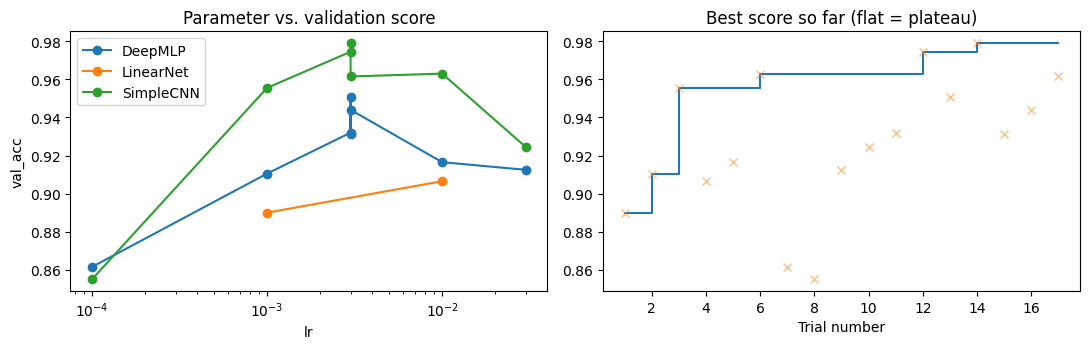

■ 試行回数: 17（目安 15 回以上） → OK
■ ベスト: trial#14 {'model': 'SimpleCNN', 'lr': 0.003, 'epochs': 4, 'hidden1': None, 'batch_size': 64}  val_acc=0.9790
■ model: 3 種類を試した
■ lr: 5 種類を試した（範囲 0.0001〜0.03）
■ epochs: 2 種類を試した
■ hidden1: 4 種類を試した
■ batch_size: 2 種類を試した
■ 仮説を書いた試行: 17/17
■ 前半の最高 0.9555 → 後半の最高 0.9790
探索に使った時間の合計: 117 秒


In [12]:
# === 経過の確認（何度でも実行）：次の一手を決める材料 ===
display(lab.df().drop(columns="hypothesis").sort_values("val_acc", ascending=False).head(8))
lab.plot(x="lr", group="model")                # lr と検証精度、ベスト更新の推移
lab.report(min_trials=15)
print("探索に使った時間の合計: %.0f 秒" % sum(r["extra"]["sec"] for r in lab.rows))

In [13]:
# === ✍️ 問題2 解答（採点対象）===
import pandas as pd

# (2-a) 実験ログ（自動出力。15回以上・3モデルすべて・lr を含む3軸以上を動かすこと）
experiment_log = lab.df()
print(experiment_log.drop(columns="hypothesis").to_string())
lab.save()

# (2-b) 探索の進め方：各段階で何を見て次の試行を決めたか（試行番号 #n を引用）
answer_2_b = """
【#1〜#3】lr=0.001・2 エポックで 3 モデルを同条件で比較：LinearNet 0.8900、DeepMLP 0.9105、SimpleCNN 0.9555。順位は予想どおり。
【#4〜#8】lr を 10 倍・1/10 に：0.01 で 3 モデルとも #1〜#3 より上がった（0.9065, 0.9165, 0.9630）。0.0001 は DeepMLP 0.8615、SimpleCNN 0.8550 と大きく下がった（学習不足）。最適 lr は 0.001〜0.01 の間だと絞れた。
【#9〜#12】桁の間（0.003）と上（0.03）：SimpleCNN は 0.003 で 0.9745（#12、最良）、0.03 で 0.9245（#10）と山型。DeepMLP は 0.003 で 0.9320（#11）が最良で 0.03 で 0.9125。
【#13〜#17】lr=0.003 で epochs・hidden1・batch_size を動かした：epochs=4 で DeepMLP 0.9505（#13）、SimpleCNN 0.9790（#14、最良）。hidden1=64/512 は 0.9315/0.9440。batch_size=256 は 0.9615（#17）で 64 の 0.9745 より低い。
"""

# (2-c) 仮説が外れた試行を1つ以上取り上げ、なぜ外れたか・何を学んだか（#n を引用）
answer_2_c = """
仮説「Adam の標準 lr=0.001 が最良」は外れた。3 モデルとも 0.003〜0.01 の方が高い（SimpleCNN: #3 0.9555 → #12 0.9745、DeepMLP: #2 0.9105 → #11 0.9320）。学習が 2 エポックと短いので、大きめの lr の方が収束が速い。もう 1 つ、仮説「batch_size を大きくすれば安定して精度が上がる」も外れた（#17: 256 で 0.9615 < #12: 64 で 0.9745）。同じ 2 エポックでは大きいバッチは更新回数が 1/4 になり、学習が足りない。
"""

# (2-d) 実験前の予測（prediction_2_*）と実際を比べる。どこがズレた？ 正しかった知識／間違っていた知識は？
answer_2_d = """
予測は「SimpleCNN > DeepMLP > LinearNet、lr=0.001」。順位は当たり（最良は 0.9790 / 0.9505 / 0.9065）。lr は外れ（最良は 0.003）。原因は、標準の lr を短い学習にそのまま当てはめたこと。正しかった知識：局所特徴を捉える CNN が有利。間違っていた知識：最適な lr の桁。
"""

# (2-e) 考察1：複雑なモデルほど精度が上がったか／違ったら理由（#n を引用。差が偶然の範囲でないかにも触れる）
reflection1 = """
LinearNet < DeepMLP < SimpleCNN の順に上がった。各モデルの最良は LinearNet 0.9065（#4）、DeepMLP 0.9505（#13）、SimpleCNN 0.9790（#14）で、差（0.044 と 0.0285）はシード違いの幅（数ポイント以下）を大きく超えている（同じ lr=0.003・2 エポックの #11 と #12 でも 0.9320 と 0.9745 で差 0.0425）。同条件（lr=0.001, #1〜#3）でも同じ順位なので、順位は偶然ではない。予想通りだったが、DeepMLP が LinearNet に対して思ったほど伸びなかった（+0.044）のは、エポックが短いことも一因。
"""

# (2-f) 考察2：学習率が大きすぎると学習がうまくいかない理由（#n を引用）
reflection2 = """
lr は 1 ステップで重みを動かす大きさ。大きすぎると更新が最小値を飛び越えて損失が振動し、学習が不安定になる。SimpleCNN は lr=0.003 で 0.9745（#12）だが、0.03 では 0.9245（#10）と 0.05 下がり、gap（train−val）も 0.0135 で train も 0.938 と低い＝収束できていない。小さすぎる場合（0.0001: #8 は 0.8550）は学習が進まない。
"""

# (2-g) 考察3：n_params・sec と val_acc の関係。精度を 0.5 ポイント上げるのに何倍のコストがかかった例
answer_2_g = """
SimpleCNN の epochs を 2 → 4（#12 → #14）にすると val_acc は 0.9745 → 0.9790（+0.0045）だが、時間は 7.9 秒 → 15.3 秒（約 2 倍）。精度 0.5 ポイントの上積みに約 2 倍のコストがかかった。DeepMLP の hidden1 を 64 → 512（#15 → #16）にすると 0.9315 → 0.9440（+0.0125）だがパラメータ数は 59,850 → 468,874（約 7.8 倍）。CNN と MLP の比較では、SimpleCNN は DeepMLP より 2.3 倍遅い（7.9 秒 vs 3.4 秒）が、パラメータ数は少なく（206,922 vs 235,146）精度は +0.0425。
"""

    trial      model      lr  epochs  hidden1  batch_size  val_acc  train_acc     gap  n_params   sec
0       1  LinearNet  0.0010       2      NaN          64   0.8900     0.8860 -0.0040      7850   2.8
1       2    DeepMLP  0.0010       2    256.0          64   0.9105     0.9240  0.0135    235146   4.0
2       3  SimpleCNN  0.0010       2      NaN          64   0.9555     0.9605  0.0050    206922   9.6
3       4  LinearNet  0.0100       2      NaN          64   0.9065     0.9280  0.0215      7850   2.9
4       5    DeepMLP  0.0100       2    256.0          64   0.9165     0.9460  0.0295    235146   4.0
5       6  SimpleCNN  0.0100       2      NaN          64   0.9630     0.9760  0.0130    206922   9.0
6       7    DeepMLP  0.0001       2    256.0          64   0.8615     0.8650  0.0035    235146   4.7
7       8  SimpleCNN  0.0001       2      NaN          64   0.8550     0.8590  0.0040    206922   8.7
8       9    DeepMLP  0.0300       2    256.0          64   0.9125     0.9415  0.0

## 問題3　精度比較と「伸びないときの対処」の選択　【骨格+選択】
***

### 棒グラフで比較する際のポイント

精度の差が小さい（例：97% vs 99%）場合，y軸を 0.95〜1.0 に絞ると差が見やすくなる：

```python
plt.ylim(0.95, 1.0)
```

ただし **y軸を切り捨てる（truncated y-axis）** のは，差を誇張して見せることになるため，学術的な文脈では注意が必要だ。常に「実際の差の大きさ」を意識すること。

### 課題

下のコードセルは、問題2の探索ログから**モデルごとの最良検証精度**を集めて棒グラフにします。**核心（精度リストの取り出し）はあなたが書きます**（`# ★あなたが書く★`）。書いて実行し、結果を確認してください。

そのうえで、次の **設計判断** に答えてください。

> **設計判断**: あなたのモデルの精度が「思ったより伸びない」とき、次のうち**効果がありそうな対処を2つ以上選び**、それぞれ「なぜ効くと思うか」を解答用コードセルに書いてください。**やみくもに全部やるのではなく、状況に応じて選ぶ**のが大事です。
>
> - **(A) epoch を増やす** … 学習回数を増やす
> - **(B) 学習率(lr)を調整する** … 大きすぎ/小さすぎを直す
> - **(C) Dropout などの正則化を入れる** … 過学習を抑える
> - **(D) データ拡張（回転・平行移動）を行う** … 学習データを水増し
> - **(E) 層やチャネルを増やしてモデルを複雑にする** … 表現力を上げる
> - **(F) Batch Normalization を入れる** … 各層の出力を正規化して学習を安定・高速化
>
> ヒント：「訓練精度は高いが検証精度が低い（＝過学習）」のか、「訓練精度自体が低い（＝表現力/学習不足）」のかで、選ぶべき対処は変わります。**問題2の実験ログの train_acc / val_acc / gap の数値を根拠にして選んでください。**

> **考察3**: モデルの複雑さ（パラメータ数）と精度の関係はどうでしたか？ パラメータが多いほど常に精度が上がりましたか？


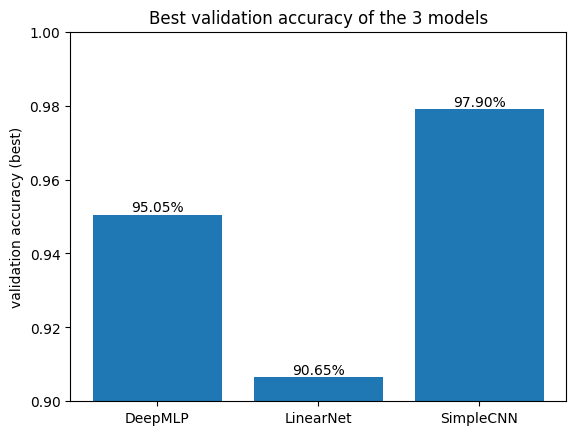

最高精度モデル: SimpleCNN (97.90%)


In [14]:
# === 用意済み：問題2の探索ログから、モデルごとの最良検証精度を集める ===
results = lab.df().groupby("model")["val_acc"].max().to_dict()   # {モデル名: 最良の検証精度}
names = list(results.keys())

# ★あなたが書く★：results から各モデルの正解率を取り出して accs（リスト）を作る（1行）
#   ヒント: results は {モデル名: 正解率} の辞書。names の順に値を並べる
accs = [results[n] for n in names]

# === 用意済み：棒グラフ描画 ===
plt.bar(names, accs)
plt.ylim(0.9, 1.0)  # 差を見やすくするため軸を絞っている（誇張に注意）
for i, a in enumerate(accs):
    plt.text(i, a, f"{a * 100:.2f}%", ha="center", va="bottom")
plt.ylabel("validation accuracy (best)")
plt.title("Best validation accuracy of the 3 models")
plt.show()

best = max(results, key=results.get)
print("最高精度モデル:", best, f"({results[best] * 100:.2f}%)")


In [15]:
# === ✍️ 問題3 解答（採点対象）===

# (3-a) 設計判断：精度が伸びないときに選んだ対処（A〜F から2つ以上）：(　)(　)
# (A) epoch を増やす
# (B) 学習率(lr)を調整する
# (C) Dropout などの正則化を入れる
# (D) データ拡張（回転・平行移動）を行う
# (E) 層やチャネルを増やしてモデルを複雑にする
# (F) Batch Normalization を入れる
design3_choice = "B, C"
# (3-b) 選んだ対処1が効く理由
answer_3_b = """
(B) 学習率を調整する：#3 → #12 のように lr を 0.001 → 0.003 に変えるだけで SimpleCNN は +0.019、DeepMLP も +0.0215 上がった（#2 → #11）。最も安く効く対処で、まず最初にやる。lr が大きすぎても小さすぎても悪化するので探索が必要。
"""

# (3-c) 選んだ対処2が効く理由
answer_3_c = """
(C) Dropout などの正則化：DeepMLP は #13 で train_acc 0.98 / val 0.9505（gap 0.0295）と過学習気味（epochs=4 で gap が #11 の 0.0165 から拡大）。訓練データに合わせすぎているので、Dropout でランダムにユニットを落として特定のユニットへの依存を減らすのが有効。SimpleCNN は gap 0.015 と小さいので、正則化より epochs を増やす（A）方が効く。
"""

# (3-d) 考察3：パラメータ数と精度の関係（多いほど常に上がるか）
reflection3 = """
パラメータが多いほど常に精度が上がるわけではない。SimpleCNN（206,922）は DeepMLP（235,146）よりパラメータが少ないのに精度が高い（0.9745 vs 0.9320、lr=0.003・2 エポック）。同じ DeepMLP で hidden1 を増やすと 59,850 → 235,146 → 468,874 で 0.9315 → 0.9320 → 0.9440 と増えるが、増加は緩やか。精度を決めるのは、パラメータ数より構造（画像の局所性に合っているか）。
"""



## 問題4　混同行列の解釈とモデル保存　【説明+選択】
***

### 混同行列から何を読み取るか

10クラス（数字0〜9）の混同行列は 10×10 のヒートマップになる。対角線が正解，対角線以外が誤分類だ。

よく混同される数字の例：
- **1 と 7**: 縦棒の形が似ている
- **3 と 8**: 右側のカーブが似ている（特に崩した字体）
- **4 と 9**: 縦線と右下のカーブが似ている
- **5 と 6**: どちらも上が開いた形

「どのクラスが最も多く誤分類されているか」を確認し，その数字の特徴を考えてみよう。

### 混同行列から改善策を考える

特定のクラスで誤分類が多い場合の対処法：
- そのクラスのデータを増やす（Data Augmentation）
- クラス不均衡対策（第12回の `class_weight`）
- モデルを複雑にする
- 前処理の改善（画像の回転・スケール正規化）

### モデルの保存

第17回では保存した `best_mnist_model.pth` を読み込んで使用する。**ファイル名と保存先を正確に一致させること**が重要だ。

### 課題

下のコードセルは、問題2で見つけた **SimpleCNN の最良設定**（第17回で SimpleCNN の構造に重みを読み込むため、ここでは SimpleCNN に限定します）で検証用 2000 枚を除いた訓練データ（58000 枚）で再学習し、**テストデータで 1回だけ最終評価**して混同行列を描き、`best_mnist_model.pth` を保存します（第17回で使用）。**核心（テストデータの予測ラベルを集める1行）はあなたが書きます**（`# ★あなたが書く★`）。

混同行列を**読み取って**、次に答えてください。

> **設計判断（読み取り＋対処）**:
> 1. あなたの混同行列で「**最も混同されている数字のペア**」を2〜3個挙げてください（解答用コードセルに記入）。
> 2. その誤分類を減らすには、問題3の対処 (A)〜(F) のうちどれが有効そうですか？ **1つ選んで理由**を書いてください。
>
> ヒント：よく混同される例 — 1と7（縦棒）/ 3と8（右のカーブ）/ 4と9（縦線と右下）/ 5と6（上が開いた形）。

> **考察4**: 混同行列の「対角線」は何を表しますか？ また、特定の数字だけ誤分類が多い場合、それはデータの問題（その数字の枚数が少ない等）かモデルの問題か、どう切り分けますか？

58000 枚で再学習した SimpleCNN の検証精度 = 0.9880


最終テストスコア = 0.9895   （検証ベスト val_acc = 0.9790）
採用した設定: {'model': 'SimpleCNN', 'lr': 0.003, 'epochs': 4, 'hidden1': None, 'batch_size': 64}


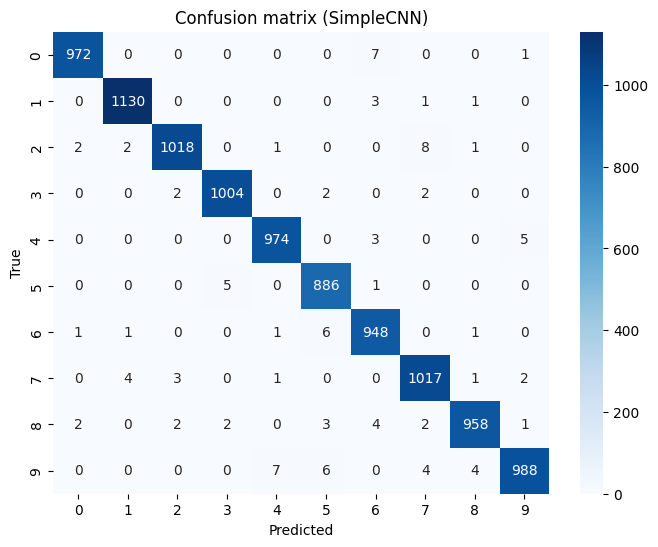

正解 2 → 予測 7: 8 件
正解 9 → 予測 4: 7 件
正解 0 → 予測 6: 7 件
正解 9 → 予測 5: 6 件
正解 6 → 予測 5: 6 件
保存しました: best_mnist_model.pth


In [16]:
# === 完成済みコード：最良設定で再学習し、テストデータで「1回だけ」最終評価する ===
# 第17回は SimpleCNN の構造で重みを読み込むので、保存するモデルは SimpleCNN にする（SimpleCNN の中で検証最良の設定を既定にする）
cnn_rows = [r for r in lab.rows if r["params"]["model"] == "SimpleCNN"]
FINAL = dict(max(cnn_rows, key=lambda r: r["score"])["params"])   # 選び直すなら書き換える（理由は解答欄へ）
if FINAL != lab.best()["params"]:
    print("注意: 全体の検証最良は", lab.best()["params"], "→ 第17回で使うため SimpleCNN の最良を採用します")
best = FINAL["model"]
EPOCHS, LR = FINAL["epochs"], FINAL["lr"]     # 第17回で再学習する場合のために残す
torch.manual_seed(0)
best_model = build_model(best, FINAL["hidden1"])
# 検証用 2000 枚（50000〜52000 番）を除いた 58000 枚で学習。評価には検証データを使う（テストは見ない）
train_idx = list(range(0, 50000)) + list(range(52000, 60000))
full_loader = DataLoader(Subset(train_dataset, train_idx), batch_size=FINAL["batch_size"], shuffle=True)
val_acc_full = train_one_model(best_model, full_loader, val_loader, epochs=EPOCHS, lr=LR)
print(f"58000 枚で再学習した {best} の検証精度 = {val_acc_full:.4f}")

# テストデータ全体の予測を集める
best_model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        # ★あなたが書く★：best_model の出力から予測ラベル preds を求める（1行）
        #   ヒント: model(images) の出力（logits）に .argmax(dim=1) を取り、.cpu() で CPU へ
        preds = best_model(images).argmax(dim=1).cpu()
        y_pred.extend(preds.numpy())
        y_true.extend(labels.numpy())

lab.final_test(lambda: float(np.mean(np.array(y_true) == np.array(y_pred))))   # ← テストの評価はここで1回だけ
print("採用した設定:", FINAL)

# 混同行列のヒートマップ
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion matrix ({best})")
plt.show()

# 混同の多い（正解 → 予測）ペア上位 5 件（対角線＝正解は除く）。ヒートマップと見比べる
_off = [(cm[i, j], i, j) for i in range(10) for j in range(10) if i != j]
for _n, _i, _j in sorted(_off, reverse=True)[:5]:
    print(f"正解 {_i} → 予測 {_j}: {_n} 件")

# 第17回で使うモデルを保存
torch.save(best_model.state_dict(), "best_mnist_model.pth")
print("保存しました: best_mnist_model.pth")

In [17]:
# === ✍️ 問題4 解答（採点対象）===

# (4-a) 混同されやすい数字のペア（2〜3個）
answer_4_a = """
正解 2 → 予測 7（8 件）、正解 9 → 予測 4（7 件）、正解 0 → 予測 6（7 件）。次いで 9 → 5、6 → 5（各 6 件）。
"""

# (4-b) それを減らすのに有効な対処（問題3の対処 A〜F から1つ）：(　)
# (A) epoch を増やす
# (B) 学習率(lr)を調整する
# (C) Dropout などの正則化を入れる
# (D) データ拡張（回転・平行移動）を行う
# (E) 層やチャネルを増やしてモデルを複雑にする
# (F) Batch Normalization を入れる
answer_4_b = "D"
# (4-c) その理由
answer_4_c = """
(D) データ拡張（回転・平行移動）。2 と 7、9 と 4 は、書き方の癖（線の傾き・位置・はねの有無）で形が似る。回転・平行移動でこうした変動を訓練データに増やせば、モデルが 1 つの典型的な形に頼らず、変動に強い特徴を学習できる。誤分類は総数で 1% 程度（テスト 10000 件中 100 件強）で、特定の 1 クラスに偏っていない（最多でも 8 件）ので、epoch を増やすなどの汎用的な対処より、形のばらつきへの対処が合う。
"""

# (4-d) 考察4：混同行列の「対角線」は何を表すか
answer_4_d = """
対角線は、正解ラベルと予測ラベルが一致した（正しく分類された）件数。対角線の値が大きいほど精度が高く、対角線以外は誤分類。
"""

# (4-e) 考察4：特定の数字だけ誤分類が多いとき、データの問題かモデルの問題かをどう切り分けるか
answer_4_e = """
①クラスごとの訓練データの枚数を確認する（MNIST は各クラス約 6000 枚でほぼ均等なので、枚数の偏りは原因になりにくい）。②誤分類された画像を実際に見る（ラベルが誤っている、形が本当に曖昧、など）。③別のモデル（例：LinearNet や DeepMLP）でも同じ数字が誤分類されるか調べる。全モデルで同じなら、データ（本質的に曖昧な画像）の問題。モデルによって変わるなら、モデルの表現力・学習の問題。④クラスごとの再現率を出して比較する。
"""

# (4-f) 最終テスト精度と、検証精度（探索時の最良・58000 枚で再学習後）の比較。差をどう解釈するか。報告する性能はどれか
answer_4_f = """
最終テスト精度は 0.9895。検証精度は、探索時の最良（2000 枚・12000 枚学習）が 0.9790、58000 枚で再学習後が 0.9880。再学習後の検証（0.9880）とテスト（0.9895）の差は 0.0015 で、ほぼ一致している（検証 2000 枚の 1 件が 0.0005）。探索時の 0.9790 が低いのは、学習枚数が 12000 枚と少なかったため。報告する性能は、探索に使っていないテストの 0.9895。
"""
